In [1]:
!pip install -q datasets transformers evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import re

In [3]:
from datasets import load_dataset

dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [5]:
import pandas as pd

train_df = pd.DataFrame(dataset["train"])
test_df = pd.DataFrame(dataset["test"])

print("Training data:", train_df.shape)
print("Testing data:", test_df.shape)

train_df.head()

Training data: (25000, 2)
Testing data: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video sto...,0
1,"""I Am Curious: Yellow"" is a risible and preten...",0
2,If only to avoid making this type of film in t...,0
3,This film was probably inspired by Godard's Ma...,0
4,"Oh, brother...after hearing about this ridicul...",0


In [6]:
print(train_df.info())
print()
print(train_df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    25000 non-null  object
 1   label   25000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB
None

label
0    12500
1    12500
Name: count, dtype: int64


In [7]:
for i in range(3):
    print("Review:", train_df.loc[i, "text"])
    print("Sentiment:", "Positive" if train_df.loc[i, "label"] == 1 else "Negative")
    print("-" * 80)

Review: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far betw

In [8]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [10]:
import re

train_df["clean_text"] = train_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

train_df[["text", "clean_text"]].head()

,text,clean_text
0,I rented I AM CURIOUS-YELLOW from my video sto...,i rented i am curious yellow from my video sto...
1,"""I Am Curious: Yellow"" is a risible and preten...",i am curious yellow is a risible and pretentio...
2,If only to avoid making this type of film in t...,if only to avoid making this type of film in t...
3,This film was probably inspired by Godard's Ma...,this film was probably inspired by godard s ma...
4,"Oh, brother...after hearing about this ridicul...",oh brother after hearing about this ridiculous...


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer(max_features=10000, stop_words='english')

# Fit on training clean_text and transform both sets
X_train = vectorizer.fit_transform(train_df["clean_text"])
X_test = vectorizer.transform(test_df["clean_text"])

y_train = train_df["label"].values
y_test = test_df["label"].values

print("TF-IDF representation complete.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

TF-IDF representation complete.
X_train shape: (25000, 10000)
X_test shape: (25000, 10000)


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8812

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88     12500
           1       0.88      0.88      0.88     12500

    accuracy                           0.88     25000
   macro avg       0.88      0.88      0.88     25000
weighted avg       0.88      0.88      0.88     25000



In [14]:
from sklearn.model_selection import train_test_split

X = train_df["clean_text"]
y = train_df["label"]

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))

Training samples: 20000
Validation samples: 5000


In [15]:
tfidf = TfidfVectorizer(
    max_features=10000,
    stop_words="english",
    ngram_range=(1, 2)
)

In [16]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)

Training TF-IDF shape: (20000, 10000)
Validation TF-IDF shape: (5000, 10000)


In [17]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

print("Model training completed!")

Model training completed!


In [18]:
y_pred = lr_model.predict(X_val_tfidf)
y_prob = lr_model.predict_proba(X_val_tfidf)

print(y_pred[:10])

[1 0 0 0 1 0 1 0 0 0]


In [20]:
from sklearn.metrics import accuracy_score, f1_score

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print("TF-IDF + Logistic Regression")
print("Accuracy:", round(accuracy, 4))
print("F1 Score:", round(f1, 4))

TF-IDF + Logistic Regression
Accuracy: 0.892
F1 Score: 0.8935


In [21]:
print(classification_report(
    y_val,
    y_pred,
    target_names=["Negative", "Positive"]
))

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      2500
    Positive       0.88      0.91      0.89      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



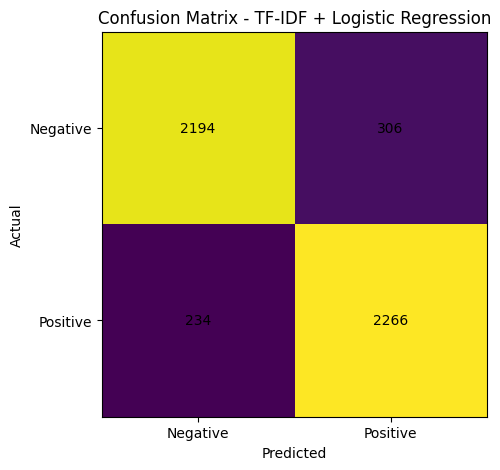

In [23]:
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
plt.imshow(cm)

plt.title("Confusion Matrix - TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Negative", "Positive"])
plt.yticks([0, 1], ["Negative", "Positive"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

In [24]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    vector = tfidf.transform([cleaned])

    prediction = lr_model.predict(vector)[0]
    probabilities = lr_model.predict_proba(vector)[0]

    sentiment = "Positive" if prediction == 1 else "Negative"
    confidence = probabilities[prediction]

    return sentiment, confidence

In [25]:
reviews = [
    "This movie was absolutely amazing and I loved every minute of it.",
    "The movie was boring and a complete waste of time.",
    "The acting was excellent and the story was very interesting.",
    "I hated this movie. It was terrible and disappointing."
]

for review in reviews:
    sentiment, confidence = predict_sentiment(review)

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 80)

Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive
Confidence: 89.45 %
--------------------------------------------------------------------------------
Review: The movie was boring and a complete waste of time.
Prediction: Negative
Confidence: 99.09 %
--------------------------------------------------------------------------------
Review: The acting was excellent and the story was very interesting.
Prediction: Positive
Confidence: 85.98 %
--------------------------------------------------------------------------------
Review: I hated this movie. It was terrible and disappointing.
Prediction: Negative
Confidence: 98.59 %
--------------------------------------------------------------------------------


In [26]:
results = pd.DataFrame({
    "text": X_val.values,
    "actual": y_val.values,
    "predicted": y_pred,
    "confidence": y_prob.max(axis=1)
})

wrong_predictions = results[
    results["actual"] != results["predicted"]
]

print("Wrong predictions:", len(wrong_predictions))

wrong_predictions.head(10)

Wrong predictions: 540


,text,actual,predicted,confidence
1,this is a must see for independant movie fans ...,1,0,0.525077
9,yowsa if you really want some action check out...,1,0,0.710688
29,despite its budget limitations this is a great...,1,0,0.566047
32,i rated this a ten just because i find it so i...,1,0,0.871949
48,a long time ago i watched this movie from the ...,1,0,0.555675
57,this movie tackles child abduction from the po...,0,1,0.540398
89,i saw this film over the weekend and while i w...,0,1,0.639585
90,i waited a while to post a review of this docu...,1,0,0.513958
94,i agree with all the accolades i went through ...,1,0,0.507443
101,with this topic it is so easy to take cheap sh...,1,0,0.640914


In [27]:
for _, row in wrong_predictions.head(5).iterrows():

    actual = "Positive" if row["actual"] == 1 else "Negative"
    predicted = "Positive" if row["predicted"] == 1 else "Negative"

    print("Review:", row["text"][:500])
    print("Actual:", actual)
    print("Predicted:", predicted)
    print("Confidence:", round(row["confidence"] * 100, 2), "%")
    print("-" * 80)

Review: this is a must see for independant movie fans but it also holds up well against mainstream movies i think we have the makings of the next woody allen or trentin tarrentino here the budget is painfully low no special effects whatsoever and they seemingly used ambient lighting shot in digital video and yet this movie grabs hold of you and never lets go the screenplay is somewhat bizarre yet the actors and director pull it off with complete realism it has humor it has intrigue and it has pathos and
Actual: Positive
Predicted: Negative
Confidence: 52.51 %
--------------------------------------------------------------------------------
Review: yowsa if you really want some action check out the babes and bombs on this non stop thriller veteran star martin sheen leads a trio of supermodels on a mission to stop nuclear terrorism but director dean hamilton doesn t let this heavy plotline get in the way of massive doses of teensy swimsuit scenes jiggly beach jogs hubba hubba hot tubs and

In [28]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

import torch

In [29]:
train_small = dataset["train"].shuffle(seed=42).select(range(8000))
val_small = dataset["test"].shuffle(seed=42).select(range(2000))

print("Training samples:", len(train_small))
print("Validation samples:", len(val_small))

Training samples: 8000
Validation samples: 2000


In [30]:
model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [31]:
def tokenize_data(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_tokenized = train_small.map(tokenize_data, batched=True)
val_tokenized = val_small.map(tokenize_data, batched=True)

print(train_tokenized)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8000
})


In [32]:
train_tokenized = train_tokenized.remove_columns(["text"])
val_tokenized = val_tokenized.remove_columns(["text"])

train_tokenized.set_format("torch")
val_tokenized.set_format("torch")

In [33]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [34]:
def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [35]:
training_args = TrainingArguments(
    output_dir="./distilbert_results",
    eval_strategy="epoch",
    save_strategy="no",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=2,
    weight_decay=0.01,
    logging_steps=100,
    report_to="none"
)

In [36]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    compute_metrics=compute_metrics
)

In [38]:
import numpy as np

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.260184,0.393302,0.856500,0.857427
2,0.173751,0.465410,0.853000,0.858654


Epoch,Training Loss,Validation Loss


TrainOutput(global_step=1000, training_loss=0.22219554042816161, metrics={'train_runtime': 214.1585, 'train_samples_per_second': 74.711, 'train_steps_per_second': 4.669, 'total_flos': 529869594624000.0, 'train_loss': 0.22219554042816161, 'epoch': 2.0})

In [39]:
transformer_results = trainer.evaluate()

print(transformer_results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.173751,0.465410,2,0.853000,0.858654


{'eval_loss': 0.4654099643230438, 'eval_accuracy': 0.853, 'eval_f1': 0.8586538461538461}


In [40]:
predictions = trainer.predict(val_tokenized)

transformer_pred = np.argmax(
    predictions.predictions,
    axis=1
)

transformer_prob = torch.softmax(
    torch.tensor(predictions.predictions),
    dim=1
).numpy()

print(transformer_pred[:10])

[1 1 0 1 0 1 1 0 0 1]


In [41]:
def transformer_predict(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    device = model.device

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = torch.softmax(outputs.logits, dim=1)

    prediction = torch.argmax(probabilities, dim=1).item()

    confidence = probabilities[0][prediction].item()

    sentiment = "Positive" if prediction == 1 else "Negative"

    return sentiment, confidence

In [42]:
for review in reviews:

    sentiment, confidence = transformer_predict(review)

    print("Review:", review)
    print("Prediction:", sentiment)
    print("Confidence:", round(confidence * 100, 2), "%")
    print("-" * 80)

Review: This movie was absolutely amazing and I loved every minute of it.
Prediction: Positive
Confidence: 99.21 %
--------------------------------------------------------------------------------
Review: The movie was boring and a complete waste of time.
Prediction: Negative
Confidence: 99.64 %
--------------------------------------------------------------------------------
Review: The acting was excellent and the story was very interesting.
Prediction: Positive
Confidence: 98.97 %
--------------------------------------------------------------------------------
Review: I hated this movie. It was terrible and disappointing.
Prediction: Negative
Confidence: 99.57 %
--------------------------------------------------------------------------------


In [43]:
classical_accuracy = accuracy_score(y_val, y_pred)
classical_f1 = f1_score(y_val, y_pred)

transformer_accuracy = transformer_results["eval_accuracy"]
transformer_f1 = transformer_results["eval_f1"]

comparison = pd.DataFrame({
    "Model": [
        "TF-IDF + Logistic Regression",
        "DistilBERT"
    ],
    "Accuracy": [
        classical_accuracy,
        transformer_accuracy
    ],
    "F1 Score": [
        classical_f1,
        transformer_f1
    ]
})

comparison

,Model,Accuracy,F1 Score
0,TF-IDF + Logistic Regression,0.892,0.893533
1,DistilBERT,0.853,0.858654


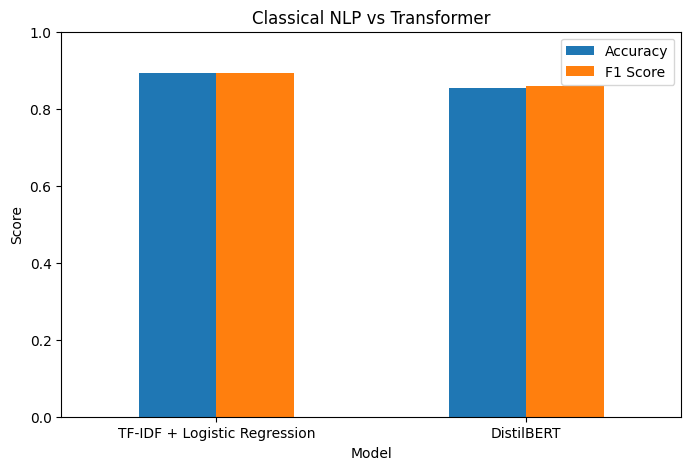

In [44]:
comparison.set_index("Model")[["Accuracy", "F1 Score"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Classical NLP vs Transformer")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.show()

In [45]:
test_reviews = [
    "This was one of the best movies I have ever watched.",
    "The story was extremely boring and poorly written.",
    "The acting was good but the movie was too long.",
    "I really enjoyed the characters and the emotional story."
]

for review in test_reviews:

    classical_sentiment, classical_conf = predict_sentiment(review)
    transformer_sentiment, transformer_conf = transformer_predict(review)

    print("Review:", review)
    print()

    print(
        "TF-IDF Model:",
        classical_sentiment,
        "| Confidence:",
        round(classical_conf * 100, 2), "%"
    )

    print(
        "DistilBERT:",
        transformer_sentiment,
        "| Confidence:",
        round(transformer_conf * 100, 2), "%"
    )

    print("=" * 90)

Review: This was one of the best movies I have ever watched.

TF-IDF Model: Positive | Confidence: 91.38 %
DistilBERT: Positive | Confidence: 99.27 %
Review: The story was extremely boring and poorly written.

TF-IDF Model: Negative | Confidence: 97.77 %
DistilBERT: Negative | Confidence: 99.47 %
Review: The acting was good but the movie was too long.

TF-IDF Model: Positive | Confidence: 52.87 %
DistilBERT: Negative | Confidence: 99.37 %
Review: I really enjoyed the characters and the emotional story.

TF-IDF Model: Positive | Confidence: 91.38 %
DistilBERT: Positive | Confidence: 99.23 %
